# Grocery Market Basket Analysis with Association Rule Mining

## Goal

This notebook applies unsupervised association rule mining to grocery transaction data.

The main goal is to discover item combinations that frequently appear together in customer baskets.

Instead of predicting a label, the notebook finds patterns such as:

- frequently purchased itemsets
- strong association rules
- products that commonly appear together
- potential cross-selling opportunities

## Main techniques

This notebook uses:

- transaction aggregation
- one-hot transaction encoding
- Apriori frequent itemset mining
- FP-Growth frequent itemset mining
- association rule metrics
- rule filtering and interpretation

In [1]:
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
dataset_path = kagglehub.dataset_download("heeraldedhia/groceries-dataset")
dataset_path = Path(dataset_path)

print("Dataset downloaded to:", dataset_path)

csv_files = list(dataset_path.rglob("*.csv"))
csv_files

Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\heeraldedhia\groceries-dataset\versions\1


[WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/heeraldedhia/groceries-dataset/versions/1/Groceries_dataset.csv')]

In [3]:
df = pd.read_csv(csv_files[0])

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.6 MB


In [5]:
def clean_column_name(name):
    name = name.strip()
    name = name.lower()
    name = name.replace(" ", "_")
    return name

df.columns = [clean_column_name(col) for col in df.columns]

df.head()

,member_number,date,itemdescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [6]:
df.columns.tolist()

['member_number', 'date', 'itemdescription']

In [7]:
df = df.rename(columns={
    "itemdescription": "item"
})

df.head()

,member_number,date,item
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [8]:
df["item"].value_counts().head(20)

item
whole milk            2502
other vegetables      1898
rolls/buns            1716
soda                  1514
yogurt                1334
root vegetables       1071
tropical fruit        1032
bottled water          933
sausage                924
citrus fruit           812
pastry                 785
pip fruit              744
shopping bags          731
canned beer            717
bottled beer           687
whipped/sour cream     662
newspapers             596
frankfurter            580
brown bread            571
pork                   566
Name: count, dtype: int64

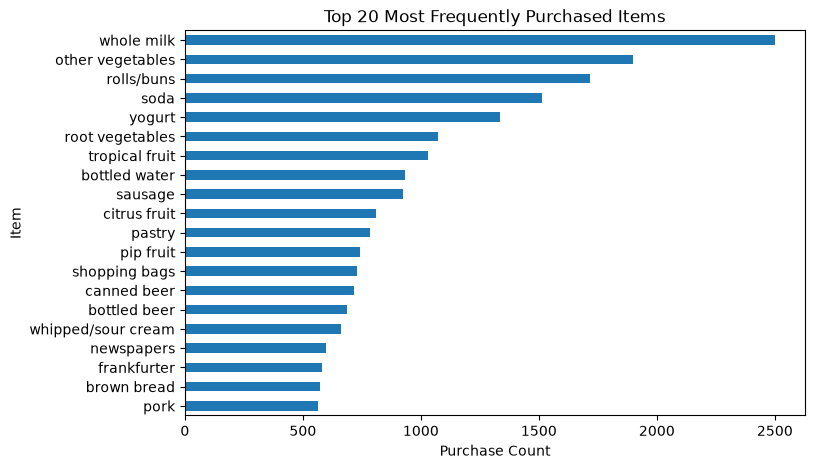

In [9]:
plt.figure(figsize=(8, 5))
df["item"].value_counts().head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Most Frequently Purchased Items")
plt.xlabel("Purchase Count")
plt.ylabel("Item")
plt.show()

## Basic inspection 

The most frequently purchased item was whole milk, with 2,502 item-level purchases.

The next most common items were other vegetables, rolls/buns, soda, yogurt, root vegetables, tropical fruit, bottled water, and sausage.

This shows that common grocery staples dominate the dataset. However, item popularity alone does not mean the item creates a useful association rule. A useful rule should also show meaningful co-occurrence with other items.

In [10]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

df["date"].isna().sum()

np.int64(0)

In [12]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

df.head()

,member_number,date,item,year,month,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,Tuesday
1,2552,2015-01-05,whole milk,2015,1,Monday
2,2300,2015-09-19,pip fruit,2015,9,Saturday
3,1187,2015-12-12,other vegetables,2015,12,Saturday
4,3037,2015-02-01,whole milk,2015,2,Sunday


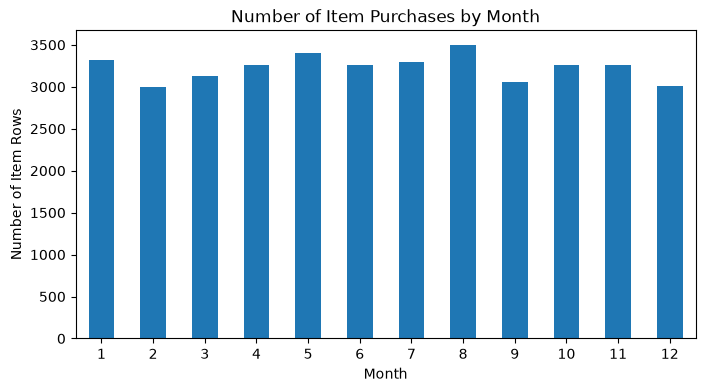

In [13]:
monthly_counts = df.groupby("month").size()

plt.figure(figsize=(8, 4))
monthly_counts.plot(kind="bar")
plt.title("Number of Item Purchases by Month")
plt.xlabel("Month")
plt.ylabel("Number of Item Rows")
plt.xticks(rotation=0)
plt.show()

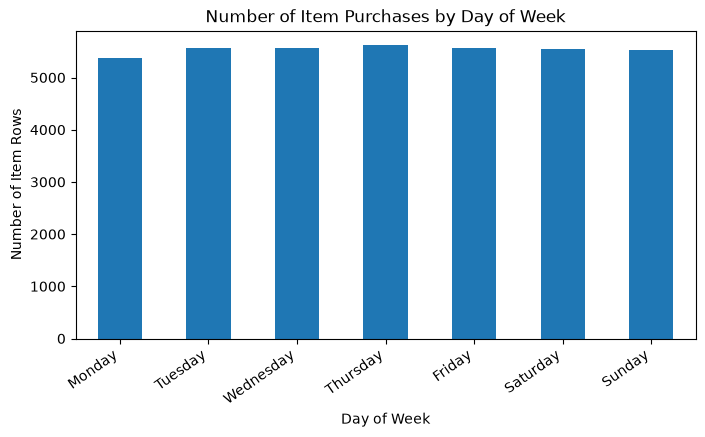

In [19]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_counts = df["day_of_week"].value_counts().reindex(day_order)

plt.figure(figsize=(8, 4))
day_counts.plot(kind="bar")
plt.title("Number of Item Purchases by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Item Rows")
plt.xticks(rotation=35, ha="right")
plt.show()

In [20]:
transactions_df = (
    df.groupby(["member_number", "date"])["item"]
    .apply(lambda items: sorted(set(items)))
    .reset_index()
)

transactions_df["basket_size"] = transactions_df["item"].apply(len)

transactions_df.head()

,member_number,date,item,basket_size
0,1000,2014-06-24,"[pastry, salty snack, whole milk]",3
1,1000,2015-03-15,"[sausage, semi-finished bread, whole milk, yog...",4
2,1000,2015-05-27,"[pickled vegetables, soda]",2
3,1000,2015-07-24,"[canned beer, misc. beverages]",2
4,1000,2015-11-25,"[hygiene articles, sausage]",2


In [21]:
print("Number of transactions:", len(transactions_df))
print("Average basket size:", transactions_df["basket_size"].mean())
print("Median basket size:", transactions_df["basket_size"].median())
print("Maximum basket size:", transactions_df["basket_size"].max())

Number of transactions: 14963
Average basket size: 2.539998663369645
Median basket size: 2.0
Maximum basket size: 10


In [22]:
transactions_df["basket_size"].describe()

count    14963.000000
mean         2.539999
std          1.060993
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         10.000000
Name: basket_size, dtype: float64

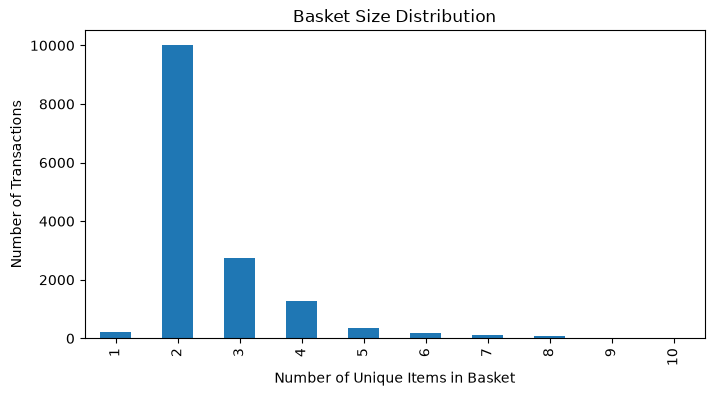

In [23]:
plt.figure(figsize=(8, 4))
transactions_df["basket_size"].value_counts().sort_index().plot(kind="bar")
plt.title("Basket Size Distribution")
plt.xlabel("Number of Unique Items in Basket")
plt.ylabel("Number of Transactions")
plt.show()

## Time pattern 

The dataset includes purchase dates, so item activity was inspected by month and day of week.

Monthly purchase activity was fairly stable, with some variation across months. Day-of-week activity was also relatively balanced, meaning there was no extreme dominance from one specific weekday.

However, the main focus of this notebook is not time forecasting. The date information is mainly used to correctly group items into transaction baskets.

## Basket creation 

Rows were grouped by member number and date to create transaction baskets.

This produced 14,963 transactions.

The average basket size was approximately 2.54 unique items, the median basket size was 2 items, and the largest basket contained 10 unique items.

The basket size distribution shows that most transactions were small, usually containing only 2 or 3 unique items. This limits how many large item combinations can be discovered.

In [24]:
multi_item_transactions_df = transactions_df[transactions_df["basket_size"] >= 2].copy()

print("Original transactions:", len(transactions_df))
print("Multi-item transactions:", len(multi_item_transactions_df))
print("Removed single-item transactions:", len(transactions_df) - len(multi_item_transactions_df))

Original transactions: 14963
Multi-item transactions: 14758
Removed single-item transactions: 205


In [25]:
transactions = multi_item_transactions_df["item"].tolist()

transactions[:5]

[['pastry', 'salty snack', 'whole milk'],
 ['sausage', 'semi-finished bread', 'whole milk', 'yogurt'],
 ['pickled vegetables', 'soda'],
 ['canned beer', 'misc. beverages'],
 ['hygiene articles', 'sausage']]

## Single-item basket filtering 

Single-item baskets were removed because they cannot produce association rules.

The original data contained 14,963 transaction baskets.

After removing single-item baskets, 14,758 multi-item transactions remained.

Only 205 single-item transactions were removed, so most baskets still contained at least two items and could be used for association rule mining.

In [26]:
encoder = TransactionEncoder()

transaction_array = encoder.fit(transactions).transform(transactions)

basket_encoded = pd.DataFrame(
    transaction_array,
    columns=encoder.columns_
)

basket_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [27]:
basket_encoded.shape

(14758, 167)

In [28]:
item_support = basket_encoded.mean().sort_values(ascending=False)

item_support.head(20)

whole milk            0.157406
other vegetables      0.122510
rolls/buns            0.109906
soda                  0.097371
yogurt                0.086055
root vegetables       0.069928
tropical fruit        0.068505
sausage               0.061052
bottled water         0.060984
citrus fruit          0.053598
pastry                0.052311
pip fruit             0.049668
shopping bags         0.047838
canned beer           0.047161
bottled beer          0.045670
whipped/sour cream    0.044179
newspapers            0.039165
frankfurter           0.038284
brown bread           0.037878
pork                  0.037471
dtype: float64

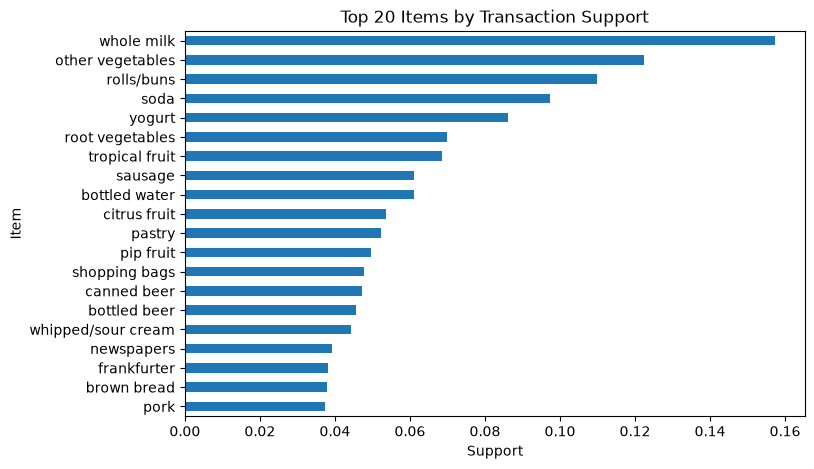

In [29]:
plt.figure(figsize=(8, 5))
item_support.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Items by Transaction Support")
plt.xlabel("Support")
plt.ylabel("Item")
plt.show()

## Transaction encoding 

The transaction baskets were converted into a one-hot encoded matrix with 14,758 rows and 167 item columns.

Each row represents one basket, and each column represents whether a specific item appeared in that basket.

The highest-support item was whole milk, appearing in about 15.74% of multi-item transactions. Other high-support items included other vegetables, rolls/buns, soda, yogurt, root vegetables, tropical fruit, sausage, and bottled water.

Support is useful for finding common items, but association rules also need confidence and lift to judge whether item relationships are meaningful.

In [30]:
MIN_SUPPORT = 0.003

apriori_itemsets = apriori(
    basket_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

apriori_itemsets["itemset_size"] = apriori_itemsets["itemsets"].apply(len)

apriori_itemsets = apriori_itemsets.sort_values(
    ["itemset_size", "support"],
    ascending=[False, False]
).reset_index(drop=True)

apriori_itemsets.head(20)

,support,itemsets,itemset_size
0,0.015043,"frozenset({whole milk, other vegetables})",2
1,0.014162,"frozenset({whole milk, rolls/buns})",2
2,0.011790,"frozenset({whole milk, soda})",2
3,0.011316,"frozenset({whole milk, yogurt})",2
4,0.010706,"frozenset({other vegetables, rolls/buns})",2
5,0.009825,"frozenset({other vegetables, soda})",2
6,0.009080,"frozenset({whole milk, sausage})",2
7,0.008334,"frozenset({whole milk, tropical fruit})",2
8,0.008199,"frozenset({other vegetables, yogurt})",2
9,0.008199,"frozenset({rolls/buns, soda})",2


In [31]:
print("Number of frequent itemsets:", len(apriori_itemsets))

apriori_itemsets["itemset_size"].value_counts().sort_index()

Number of frequent itemsets: 216


itemset_size
1    111
2    105
Name: count, dtype: int64

In [32]:
top_pair_itemsets = (
    apriori_itemsets[apriori_itemsets["itemset_size"] == 2]
    .sort_values("support", ascending=False)
    .head(15)
)

top_pair_itemsets

,support,itemsets,itemset_size
0,0.015043,"frozenset({whole milk, other vegetables})",2
1,0.014162,"frozenset({whole milk, rolls/buns})",2
2,0.011790,"frozenset({whole milk, soda})",2
3,0.011316,"frozenset({whole milk, yogurt})",2
4,0.010706,"frozenset({other vegetables, rolls/buns})",2
5,0.009825,"frozenset({other vegetables, soda})",2
6,0.009080,"frozenset({whole milk, sausage})",2
7,0.008334,"frozenset({whole milk, tropical fruit})",2
8,0.008199,"frozenset({other vegetables, yogurt})",2
9,0.008199,"frozenset({rolls/buns, soda})",2


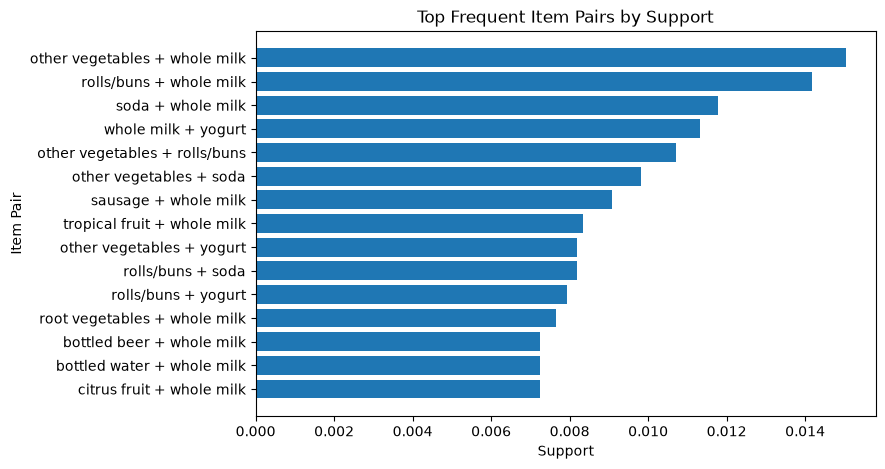

In [33]:
pair_labels = top_pair_itemsets["itemsets"].apply(lambda x: " + ".join(sorted(list(x))))

plt.figure(figsize=(8, 5))
plt.barh(pair_labels[::-1], top_pair_itemsets["support"].values[::-1])
plt.title("Top Frequent Item Pairs by Support")
plt.xlabel("Support")
plt.ylabel("Item Pair")
plt.show()

## Apriori itemsets

Using a minimum support threshold of 0.003, Apriori discovered 216 frequent itemsets.

These included:

- 111 single-item itemsets
- 105 two-item itemsets
- 0 itemsets with three or more items

The most frequent item pair was other vegetables + whole milk, with support around 0.0150.

Other common pairs included whole milk + rolls/buns, soda + whole milk, whole milk + yogurt, and other vegetables + rolls/buns.

The lack of larger itemsets makes sense because most baskets are small, with a median basket size of only 2 items.

In [34]:
fpgrowth_itemsets = fpgrowth(
    basket_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

fpgrowth_itemsets["itemset_size"] = fpgrowth_itemsets["itemsets"].apply(len)

fpgrowth_itemsets = fpgrowth_itemsets.sort_values(
    ["itemset_size", "support"],
    ascending=[False, False]
).reset_index(drop=True)

fpgrowth_itemsets.head(20)

,support,itemsets,itemset_size
0,0.015043,"frozenset({whole milk, other vegetables})",2
1,0.014162,"frozenset({whole milk, rolls/buns})",2
2,0.011790,"frozenset({whole milk, soda})",2
3,0.011316,"frozenset({whole milk, yogurt})",2
4,0.010706,"frozenset({other vegetables, rolls/buns})",2
5,0.009825,"frozenset({other vegetables, soda})",2
6,0.009080,"frozenset({whole milk, sausage})",2
7,0.008334,"frozenset({whole milk, tropical fruit})",2
8,0.008199,"frozenset({other vegetables, yogurt})",2
9,0.008199,"frozenset({rolls/buns, soda})",2


In [35]:
print("Apriori itemsets:", len(apriori_itemsets))
print("FP-Growth itemsets:", len(fpgrowth_itemsets))

Apriori itemsets: 216
FP-Growth itemsets: 216


In [36]:
apriori_sets = set(apriori_itemsets["itemsets"])
fpgrowth_sets = set(fpgrowth_itemsets["itemsets"])

print("Itemsets found by both:", len(apriori_sets.intersection(fpgrowth_sets)))
print("Only Apriori:", len(apriori_sets - fpgrowth_sets))
print("Only FP-Growth:", len(fpgrowth_sets - apriori_sets))

Itemsets found by both: 216
Only Apriori: 0
Only FP-Growth: 0


## Apriori vs FP-Growth 

Apriori and FP-Growth produced the same frequent itemsets with the same minimum support threshold.

Both methods found 216 frequent itemsets.

All 216 itemsets were found by both algorithms, with no itemsets unique to Apriori and no itemsets unique to FP-Growth.

This confirms that both algorithms produced consistent results. The main difference is algorithmic: Apriori uses candidate generation, while FP-Growth uses a more efficient pattern-growth approach.

In [37]:
rules = association_rules(
    fpgrowth_itemsets,
    metric="lift",
    min_threshold=1.0
)

rules = rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({bottled beer}),frozenset({sausage}),0.045670,0.061052,0.003388,0.074184,1.215102,1.0,0.000600,1.014185,0.185496,0.032787,0.013986,0.064839
1,frozenset({sausage}),frozenset({bottled beer}),0.061052,0.045670,0.003388,0.055494,1.215102,1.0,0.000600,1.010401,0.188534,0.032787,0.010294,0.064839
2,frozenset({frankfurter}),frozenset({other vegetables}),0.038284,0.122510,0.005218,0.136283,1.112427,1.0,0.000527,1.015947,0.105087,0.033537,0.015696,0.089436
3,frozenset({other vegetables}),frozenset({frankfurter}),0.122510,0.038284,0.005218,0.042588,1.112427,1.0,0.000527,1.004496,0.115174,0.033537,0.004476,0.089436
4,frozenset({sausage}),frozenset({yogurt}),0.061052,0.086055,0.005827,0.095450,1.109168,1.0,0.000574,1.010386,0.104823,0.041247,0.010279,0.081583
5,frozenset({yogurt}),frozenset({sausage}),0.086055,0.061052,0.005827,0.067717,1.109168,1.0,0.000574,1.007149,0.107691,0.041247,0.007098,0.081583
6,frozenset({pastry}),frozenset({sausage}),0.052311,0.061052,0.003252,0.062176,1.018419,1.0,0.000059,1.001199,0.019085,0.029538,0.001198,0.057725
7,frozenset({sausage}),frozenset({pastry}),0.061052,0.052311,0.003252,0.053274,1.018419,1.0,0.000059,1.001018,0.019262,0.029538,0.001017,0.057725
8,frozenset({sausage}),frozenset({soda}),0.061052,0.097371,0.006031,0.098779,1.014462,1.0,0.000086,1.001563,0.015183,0.039573,0.001560,0.080357
9,frozenset({soda}),frozenset({sausage}),0.097371,0.061052,0.006031,0.061935,1.014462,1.0,0.000086,1.000941,0.015794,0.039573,0.000940,0.080357


In [38]:
print("Number of rules:", len(rules))

Number of rules: 18


In [39]:
rules[["support", "confidence", "lift", "leverage", "conviction"]].describe()

,support,confidence,lift,leverage,conviction
count,18.000000,18.000000,18.000000,18.000000,18.000000
mean,0.004758,0.075485,1.056839,0.000227,1.004115
std,0.001378,0.033509,0.070936,0.000249,0.005151
min,0.003252,0.034525,1.006965,0.000026,1.000247
25%,0.003388,0.053538,1.012775,0.000059,1.000881
50%,0.004675,0.064946,1.014462,0.000063,1.001244
75%,0.005827,0.093395,1.109168,0.000527,1.006486
max,0.007250,0.158754,1.215102,0.000600,1.015947


## Association rules 

The frequent itemsets produced 18 association rules.

Overall, the rules were relatively weak. The average confidence was around 0.075, and the average lift was around 1.057.

This means most discovered rules only show a small increase over random co-occurrence.

The strongest rules still need to be interpreted carefully because the dataset contains many small baskets and many common grocery staple items.

# Association Rule Metrics

For a rule:

`A -> B`

## Support

Support measures how often A and B appear together in all transactions.

High support means the rule occurs often.

## Confidence

Confidence measures how often B appears when A appears.

It can be interpreted as:

`P(B | A)`

High confidence means the consequent is common when the antecedent appears.

## Lift

Lift compares the observed co-occurrence of A and B against what would be expected if they were independent.

- Lift greater than 1 means A and B appear together more often than expected.
- Lift equal to 1 means there is no association beyond chance.
- Lift less than 1 means A and B appear together less often than expected.

## Leverage

Leverage measures the difference between observed co-occurrence and expected co-occurrence under independence.

## Conviction

Conviction measures how strongly the absence of B depends on the absence of A. Higher conviction suggests a stronger implication-like rule.

In [40]:
def itemset_to_string(itemset):
    return ", ".join(sorted(list(itemset)))


rules_display = rules.copy()

rules_display["antecedents"] = rules_display["antecedents"].apply(itemset_to_string)
rules_display["consequents"] = rules_display["consequents"].apply(itemset_to_string)

rules_display[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction"
    ]
].head(20)

,antecedents,consequents,support,confidence,lift,leverage,conviction
0,bottled beer,sausage,0.003388,0.074184,1.215102,0.000600,1.014185
1,sausage,bottled beer,0.003388,0.055494,1.215102,0.000600,1.010401
2,frankfurter,other vegetables,0.005218,0.136283,1.112427,0.000527,1.015947
3,other vegetables,frankfurter,0.005218,0.042588,1.112427,0.000527,1.004496
4,sausage,yogurt,0.005827,0.095450,1.109168,0.000574,1.010386
5,yogurt,sausage,0.005827,0.067717,1.109168,0.000574,1.007149
6,pastry,sausage,0.003252,0.062176,1.018419,0.000059,1.001199
7,sausage,pastry,0.003252,0.053274,1.018419,0.000059,1.001018
8,sausage,soda,0.006031,0.098779,1.014462,0.000086,1.001563
9,soda,sausage,0.006031,0.061935,1.014462,0.000086,1.000941


In [41]:
top_lift_rules = rules_display.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).head(15)

top_lift_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

,antecedents,consequents,support,confidence,lift
0,bottled beer,sausage,0.003388,0.074184,1.215102
1,sausage,bottled beer,0.003388,0.055494,1.215102
2,frankfurter,other vegetables,0.005218,0.136283,1.112427
3,other vegetables,frankfurter,0.005218,0.042588,1.112427
4,sausage,yogurt,0.005827,0.095450,1.109168
5,yogurt,sausage,0.005827,0.067717,1.109168
6,pastry,sausage,0.003252,0.062176,1.018419
7,sausage,pastry,0.003252,0.053274,1.018419
8,sausage,soda,0.006031,0.098779,1.014462
9,soda,sausage,0.006031,0.061935,1.014462


In [42]:
top_confidence_rules = rules_display.sort_values(
    ["confidence", "lift", "support"],
    ascending=False
).head(15)

top_confidence_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

,antecedents,consequents,support,confidence,lift
14,bottled beer,whole milk,0.007250,0.158754,1.008561
2,frankfurter,other vegetables,0.005218,0.136283,1.112427
16,fruit/vegetable juice,rolls/buns,0.003795,0.110672,1.006965
8,sausage,soda,0.006031,0.098779,1.014462
4,sausage,yogurt,0.005827,0.095450,1.109168
10,citrus fruit,yogurt,0.004675,0.087231,1.013670
0,bottled beer,sausage,0.003388,0.074184,1.215102
12,shopping bags,root vegetables,0.003388,0.070822,1.012775
5,yogurt,sausage,0.005827,0.067717,1.109168
6,pastry,sausage,0.003252,0.062176,1.018419


## Strongest rules 

The strongest rule by lift was bottled beer → sausage, with a lift of about 1.215.

The reverse rule, sausage → bottled beer, had the same lift but lower confidence.

The highest-confidence rule was bottled beer → whole milk, with confidence around 0.159. However, its lift was only about 1.009, meaning the rule is mostly influenced by the general popularity of whole milk.

This shows why confidence alone is not enough. A rule can have high confidence simply because the consequent item is already popular. Lift is needed to check whether the relationship is stronger than expected by chance.

In [47]:
threshold_options = [
    {"support": 0.004, "confidence": 0.20, "lift": 1.20},
    {"support": 0.003, "confidence": 0.15, "lift": 1.10},
    {"support": 0.002, "confidence": 0.10, "lift": 1.05},
    {"support": 0.001, "confidence": 0.05, "lift": 1.00}
]

practical_rules = pd.DataFrame()
selected_thresholds = None

for thresholds in threshold_options:
    filtered_rules = rules[
        (rules["support"] >= thresholds["support"]) &
        (rules["confidence"] >= thresholds["confidence"]) &
        (rules["lift"] >= thresholds["lift"])
    ].copy()
    
    if len(filtered_rules) > 0:
        practical_rules = filtered_rules.copy()
        selected_thresholds = thresholds
        break

if len(practical_rules) == 0:
    print("No rules passed the adaptive thresholds. Using top 20 rules by lift instead.")
    
    practical_rules = rules.sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    ).head(20).copy()
else:
    print("Selected thresholds:")
    print(selected_thresholds)

practical_rules = practical_rules.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

practical_rules_display = practical_rules.copy()
practical_rules_display["antecedents"] = practical_rules_display["antecedents"].apply(itemset_to_string)
practical_rules_display["consequents"] = practical_rules_display["consequents"].apply(itemset_to_string)

print("Number of practical rules:", len(practical_rules_display))

practical_rules_display[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

Selected thresholds:
{'support': 0.002, 'confidence': 0.1, 'lift': 1.05}
Number of practical rules: 1


,antecedents,consequents,support,confidence,lift
0,frankfurter,other vegetables,0.005218,0.136283,1.112427


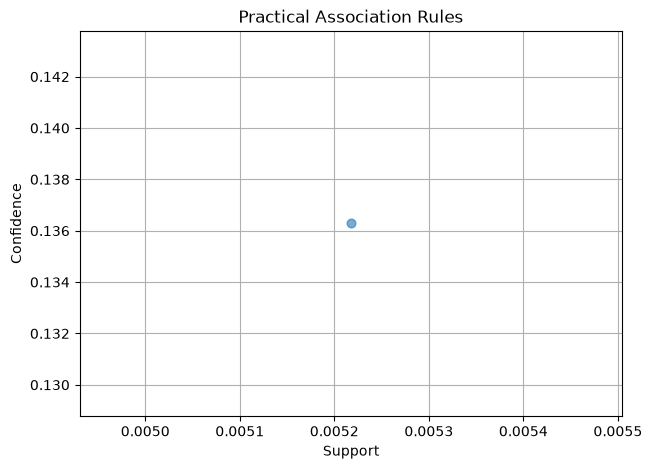

In [49]:
if len(practical_rules_display) > 0:
    plt.figure(figsize=(7, 5))
    plt.scatter(
        practical_rules_display["support"],
        practical_rules_display["confidence"],
        s=practical_rules_display["lift"] * 35,
        alpha=0.6
    )
    plt.title("Practical Association Rules")
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.grid(True)
    plt.show()
else:
    print("No practical rules found.")

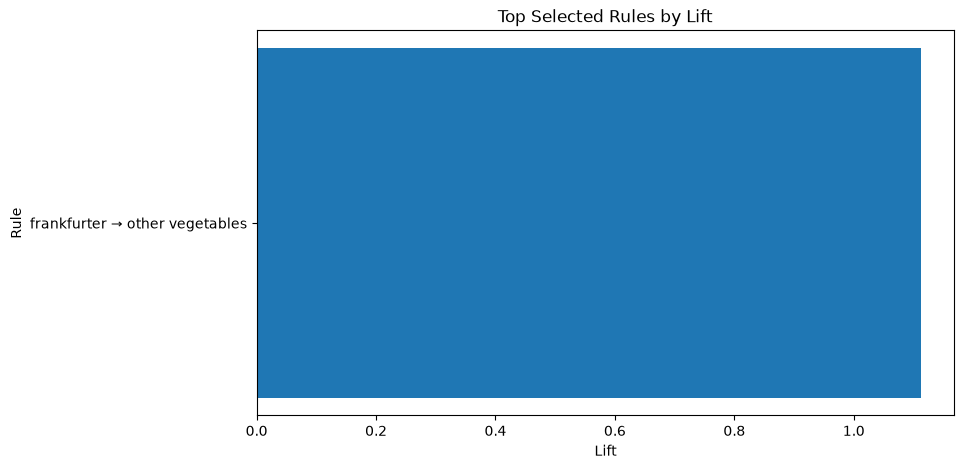

In [50]:
top_rules_for_plot = practical_rules_display.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).head(10).copy()

if len(top_rules_for_plot) > 0:
    rule_labels = (
        top_rules_for_plot["antecedents"]
        + " → "
        + top_rules_for_plot["consequents"]
    )
    
    plt.figure(figsize=(9, 5))
    plt.barh(rule_labels[::-1], top_rules_for_plot["lift"].values[::-1])
    plt.title("Top Selected Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")
    plt.show()
else:
    print("No rules available to plot.")

## Practical rule filtering note

The original strict filtering approach returned no practical rules, so adaptive filtering was used.

The selected adaptive thresholds were:

- minimum support: 0.002
- minimum confidence: 0.10
- minimum lift: 1.05

After applying these thresholds, only one practical rule remained:

frankfurter → other vegetables

This rule had:

- support: 0.005218
- confidence: 0.136283
- lift: 1.112427

This means that baskets containing frankfurter were somewhat more likely than average to also contain other vegetables, although the relationship is still moderate rather than very strong.

In [51]:
def suggest_items(input_items, rules_df, top_n=5):
    input_items = set(input_items)
    
    matched_rules = []
    
    for _, row in rules_df.iterrows():
        antecedent = set(row["antecedents"])
        consequent = set(row["consequents"])
        
        if antecedent.issubset(input_items):
            for item in consequent:
                if item not in input_items:
                    matched_rules.append({
                        "suggested_item": item,
                        "matched_antecedent": itemset_to_string(antecedent),
                        "confidence": row["confidence"],
                        "lift": row["lift"],
                        "support": row["support"]
                    })
    
    if len(matched_rules) == 0:
        return pd.DataFrame(columns=[
            "suggested_item",
            "matched_antecedent",
            "confidence",
            "lift",
            "support"
        ])
    
    suggestions = pd.DataFrame(matched_rules)
    
    suggestions = (
        suggestions.sort_values(["lift", "confidence", "support"], ascending=False)
        .drop_duplicates(subset=["suggested_item"])
        .head(top_n)
        .reset_index(drop=True)
    )
    
    return suggestions

In [52]:
all_items = sorted(basket_encoded.columns.tolist())

all_items[:30]

['Instant food products',
 'UHT-milk',
 'abrasive cleaner',
 'artif. sweetener',
 'baby cosmetics',
 'bags',
 'baking powder',
 'bathroom cleaner',
 'beef',
 'berries',
 'beverages',
 'bottled beer',
 'bottled water',
 'brandy',
 'brown bread',
 'butter',
 'butter milk',
 'cake bar',
 'candles',
 'candy',
 'canned beer',
 'canned fish',
 'canned fruit',
 'canned vegetables',
 'cat food',
 'cereals',
 'chewing gum',
 'chicken',
 'chocolate',
 'chocolate marshmallow']

In [53]:
example_basket = ["whole milk"]

suggest_items(
    input_items=example_basket,
    rules_df=practical_rules,
    top_n=5
)

,suggested_item,matched_antecedent,confidence,lift,support


In [54]:
example_basket = ["yogurt", "rolls/buns"]

suggest_items(
    input_items=example_basket,
    rules_df=practical_rules,
    top_n=5
)

,suggested_item,matched_antecedent,confidence,lift,support


## Rule visualisation note

The practical rule visualisations only show one selected rule because only one rule passed the adaptive filtering thresholds.

The remaining rule was frankfurter → other vegetables.

The scatter plot shows this rule as a single point based on support and confidence, while the bar chart shows its lift.

This result suggests that the dataset does not contain many strong practical association rules under the current support, confidence, and lift requirements.

## Product suggestion 

The product suggestion function uses practical association rules to recommend items based on the current basket.

The example baskets using whole milk and yogurt + rolls/buns returned no suggestions because none of the practical rules had those exact items as antecedents.

This is expected because only one practical rule remained after filtering: frankfurter → other vegetables.

Therefore, an input basket containing frankfurter would be the most suitable example for this rule-based suggestion function.

This is not a personalised recommender system. It only uses general item co-occurrence patterns from transaction baskets.